<a href="https://colab.research.google.com/github/sawantarya232-blip/Deep-Learning/blob/main/Assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

# Print TensorFlow version for context
print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


In [2]:
# Set parameters for data loading and preprocessing
max_features = 10000  # Only consider the top 10,000 most frequent words in the vocabulary
maxlen = 250          # Cut reviews after 250 words to ensure uniform input length

print('Loading IMDB data...')
# Load the IMDB dataset, limiting to the top `max_features` words
# x_train, x_test are sequences of word indices, y_train, y_test are sentiment labels (0 or 1)
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)
print(len(x_train), 'train sequences')
print(len(x_test), 'test sequences')

print('Padding sequences to a fixed length...')
# Pad sequences to `maxlen`. If a sequence is shorter, it's padded with zeros; if longer, it's truncated.
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)
print('x_train shape:', x_train.shape)
print('x_test shape:', x_test.shape)

Loading IMDB data...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
25000 train sequences
25000 test sequences
Padding sequences to a fixed length...
x_train shape: (25000, 250)
x_test shape: (25000, 250)


In [3]:
embedding_dim = 32 # Dimension of the word embeddings

print('Building RNN model...')
rnn_model = Sequential([
    # Embedding layer converts integer indices to dense vectors of fixed size
    Embedding(max_features, embedding_dim, input_length=maxlen),
    # SimpleRNN layer with 32 units
    SimpleRNN(32),
    # Dense output layer with sigmoid activation for binary classification (sentiment: positive/negative)
    Dense(1, activation='sigmoid')
])

# Compile the model with Adam optimizer, binary crossentropy loss, and accuracy metric
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print(rnn_model.summary())

print('Training RNN model...')
# Train the RNN model, using 20% of training data for validation
rnn_history = rnn_model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2)

# Evaluate the RNN model on the test set
rnn_loss, rnn_acc = rnn_model.evaluate(x_test, y_test, verbose=0)
print(f'RNN Test Loss: {rnn_loss:.4f}, RNN Test Accuracy: {rnn_acc:.4f}')

Building RNN model...


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Training RNN model...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 76ms/step - accuracy: 0.5979 - loss: 0.6562 - val_accuracy: 0.7824 - val_loss: 0.5129
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - accuracy: 0.8130 - loss: 0.4281 - val_accuracy: 0.8422 - val_loss: 0.3801
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.8895 - loss: 0.2780 - val_accuracy: 0.8498 - val_loss: 0.3599
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 77ms/step - accuracy: 0.9324 - loss: 0.1870 - val_accuracy: 0.8428 - val_loss: 0.4007
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.9614 - loss: 0.1152 - val_accuracy: 0.8316 - val_loss: 0.4369
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - accuracy: 0.9808 - loss: 0.0677 - val_accuracy: 0.8418 - val_loss: 0.5204
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.9904 - loss: 0.0373 - val_accuracy: 0.8104 - val_loss: 0.5875
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accurac

In [4]:
print('Building LSTM model...')
lstm_model = Sequential([
    # Embedding layer converts integer indices to dense vectors
    Embedding(max_features, embedding_dim, input_length=maxlen),
    # LSTM layer with 32 units, capable of learning long-term dependencies
    LSTM(32),
    # Dense output layer with sigmoid activation for binary classification
    Dense(1, activation='sigmoid')
])

# Compile the model with Adam optimizer, binary crossentropy loss, and accuracy metric
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print(lstm_model.summary())

print('Training LSTM model...')
# Train the LSTM model
lstm_history = lstm_model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2)

# Evaluate the LSTM model on the test set
lstm_loss, lstm_acc = lstm_model.evaluate(x_test, y_test, verbose=0)
print(f'LSTM Test Loss: {lstm_loss:.4f}, LSTM Test Accuracy: {lstm_acc:.4f}')

Building LSTM model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Training LSTM model...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 142ms/step - accuracy: 0.7441 - loss: 0.5012 - val_accuracy: 0.8526 - val_loss: 0.3593
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 42s 147ms/step - accuracy: 0.9009 - loss: 0.2613 - val_accuracy: 0.8748 - val_loss: 0.3007
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 146ms/step - accuracy: 0.9301 - loss: 0.1941 - val_accuracy: 0.8800 - val_loss: 0.3166
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 149ms/step - accuracy: 0.9483 - loss: 0.1466 - val_accuracy: 0.8798 - val_loss: 0.3222
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 163ms/step - accuracy: 0.9625 - loss: 0.1144 - val_accuracy: 0.8654 - val_loss: 0.3523
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 147ms/step - accuracy: 0.9704 - loss: 0.0942 - val_accuracy: 0.8636 - val_loss: 0.4106
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 148ms/step - accuracy: 0.9711 - loss: 0.0886 - val_accuracy: 0.8652 - val_loss: 0.4651
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 149ms/step 

In [5]:
print('Building GRU model...')
gru_model = Sequential([
    # Embedding layer converts integer indices to dense vectors
    Embedding(max_features, embedding_dim, input_length=maxlen),
    # GRU layer with 32 units, a simplified version of LSTM
    GRU(32),
    # Dense output layer with sigmoid activation for binary classification
    Dense(1, activation='sigmoid')
])

# Compile the model with Adam optimizer, binary crossentropy loss, and accuracy metric
gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print(gru_model.summary())

print('Training GRU model...')
# Train the GRU model
gru_history = gru_model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2)

# Evaluate the GRU model on the test set
gru_loss, gru_acc = gru_model.evaluate(x_test, y_test, verbose=0)
print(f'GRU Test Loss: {gru_loss:.4f}, GRU Test Accuracy: {gru_acc:.4f}')

Building GRU model...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Training GRU model...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 195ms/step - accuracy: 0.7110 - loss: 0.5312 - val_accuracy: 0.8108 - val_loss: 0.4361
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 195ms/step - accuracy: 0.8873 - loss: 0.2832 - val_accuracy: 0.8630 - val_loss: 0.3256
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 43s 208ms/step - accuracy: 0.9246 - loss: 0.2051 - val_accuracy: 0.8510 - val_loss: 0.3399
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 194ms/step - accuracy: 0.9398 - loss: 0.1636 - val_accuracy: 0.8738 - val_loss: 0.3295
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 42s 200ms/step - accuracy: 0.9492 - loss: 0.1404 - val_accuracy: 0.8718 - val_loss: 0.3563
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 197ms/step - accuracy: 0.9595 - loss: 0.1157 - val_accuracy: 0.8728 - val_loss: 0.3882
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 192ms/step - accuracy: 0.9725 - loss: 0.0865 - val_accuracy: 0.8708 - val_loss: 0.4372
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 199ms/step -

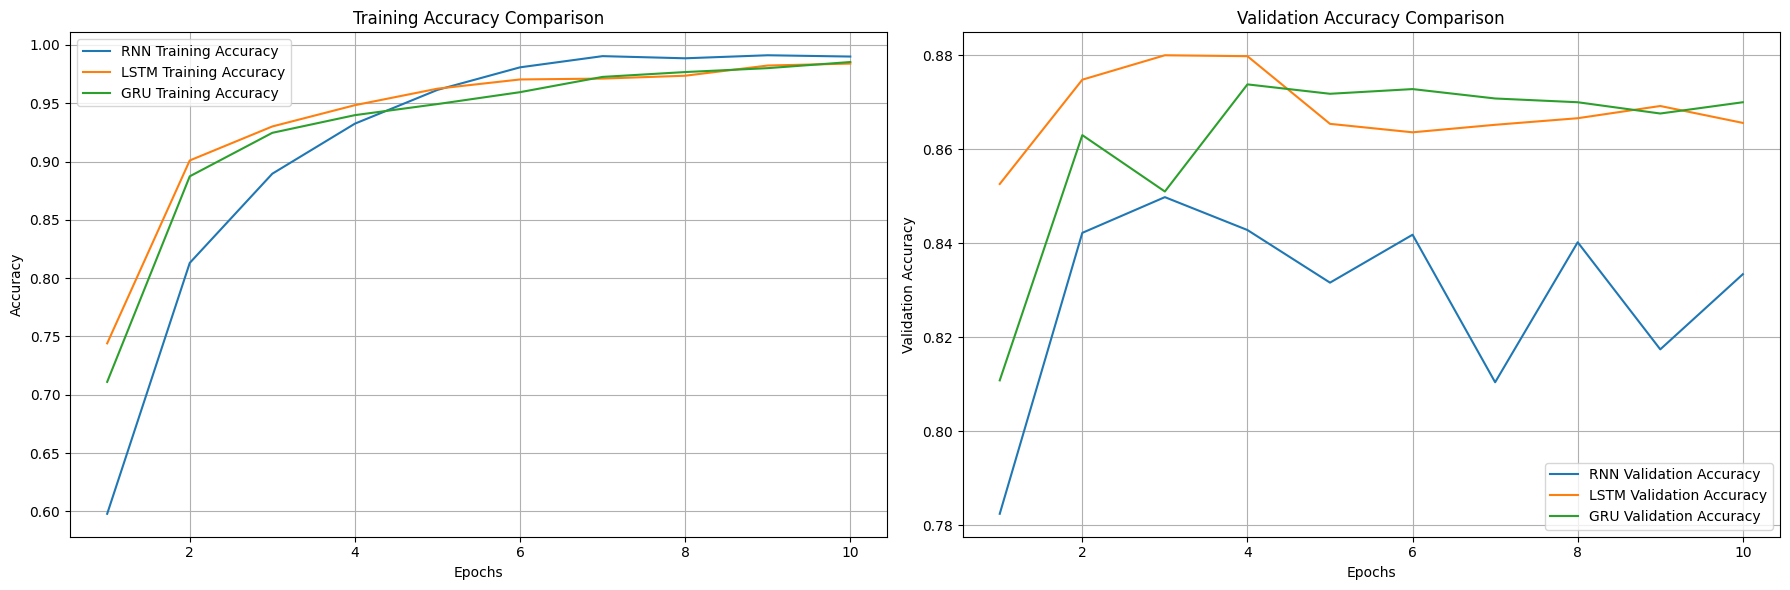


--- Final Test Performance ---
RNN  -> Loss: 0.5796, Accuracy: 0.8289
LSTM -> Loss: 0.6069, Accuracy: 0.8500
GRU  -> Loss: 0.6591, Accuracy: 0.8493

--- Conclusion ---
Based on the plots and final test metrics, we can observe:
1. Basic RNN often struggles with longer sequences, potentially showing lower accuracy or slower convergence due to vanishing gradients.
2. LSTMs and GRUs generally perform better on tasks requiring capture of long-term dependencies, as seen in their higher accuracy.
3. GRUs, being simpler than LSTMs, might converge faster or achieve comparable performance with fewer computational resources.
The exact performance can vary based on hyperparameter tuning (e.g., number of units, learning rate, embedding dimensions) and the specific dataset characteristics.


In [6]:
epochs = range(1, len(rnn_history.history['accuracy']) + 1)

plt.figure(figsize=(18, 6))

# Plot Training Accuracy for all models
plt.subplot(1, 2, 1)
plt.plot(epochs, rnn_history.history['accuracy'], label='RNN Training Accuracy')
plt.plot(epochs, lstm_history.history['accuracy'], label='LSTM Training Accuracy')
plt.plot(epochs, gru_history.history['accuracy'], label='GRU Training Accuracy')
plt.title('Training Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Validation Accuracy for all models
plt.subplot(1, 2, 2)
plt.plot(epochs, rnn_history.history['val_accuracy'], label='RNN Validation Accuracy')
plt.plot(epochs, lstm_history.history['val_accuracy'], label='LSTM Validation Accuracy')
plt.plot(epochs, gru_history.history['val_accuracy'], label='GRU Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n--- Final Test Performance ---")
print(f"RNN  -> Loss: {rnn_loss:.4f}, Accuracy: {rnn_acc:.4f}")
print(f"LSTM -> Loss: {lstm_loss:.4f}, Accuracy: {lstm_acc:.4f}")
print(f"GRU  -> Loss: {gru_loss:.4f}, Accuracy: {gru_acc:.4f}")

print("\n--- Conclusion ---")
print("Based on the plots and final test metrics, we can observe:")
print("1. Basic RNN often struggles with longer sequences, potentially showing lower accuracy or slower convergence due to vanishing gradients.")
print("2. LSTMs and GRUs generally perform better on tasks requiring capture of long-term dependencies, as seen in their higher accuracy.")
print("3. GRUs, being simpler than LSTMs, might converge faster or achieve comparable performance with fewer computational resources.")
print("The exact performance can vary based on hyperparameter tuning (e.g., number of units, learning rate, embedding dimensions) and the specific dataset characteristics.")